In [ ]:
import importlib
import plant
importlib.reload (plant)
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 

from plant import DroneConfig, DronePlant, RK4_step, b2w_rotatation, g

In [ ]:
config = DroneConfig(
    mass = 2.0, 
    inertia = np.diag([0.01, 0.01, 0.02]), 
    length = 0.2, 
    kd = 0.0, 
    kt = 0.0, 
    kb = 0.0, 
)

y0 = np.zeros (12)
dt = 0.05
t0 = 0.0
t_end = 0.5

thrust = 1.2 * config.mass * g
torques = np.array ([0.01, 0.0, 0.0])

''' 
- Thrust > gravity force => we expetc the drone to fly up 
- x-component of torques is 0.01 => we should see wx changes first, then phi changes
'''

print (f'Inertia: \n{config.inertia}'); print() 
print (f'length: {config.length}, ', f'mass: {config.mass}'); print()
print (f'RK4 coeffs: kd={config.kd}, kt={config.kt}, kb={config.kb}'); print() 
print (f'init state vec: {y0}'); print()
print (f'start: {t0}, ', f'end: {t_end}, ', f'step: {dt},' , f'time jumps: {(t_end - t0) / dt + 1}'); print()
print (f'thrust: {thrust}'); print() 
print (f'torques: {torques}'); print()

Inertia: 
[[0.01 0.   0.  ]
 [0.   0.01 0.  ]
 [0.   0.   0.02]]

length: 0.2,  mass: 2.0

RK4 coeffs: kd=0.0, kt=0.0, kb=0.0

init state vec: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

start: 0.0,  end: 0.5,  step: 0.05, time jumps: 11.0

thrust: 23.544

torques: [0.01 0.   0.  ]



In [3]:
def f(t, y): 
    plant = DronePlant (config, y) 
    return plant.state_derivatives(thrust, torques)

times = [t0]
state_vec = [y0.copy()]

t = t0 
y = y0.copy() 

while t < t_end:
    y = RK4_step(f, t, y, dt)
    t = t + dt
    times.append (t)
    state_vec.append (y.copy())

state_comp = ['x', 'y', 'z', 'vx', 'vy', 'vz', 'phi', 'theta', 'psi', 'wx', 'wy', 'wz']
df = pd.DataFrame(state_vec, columns = state_comp)
df.insert (0, 'time', times)
df

,time,x,y,z,vx,vy,vz,phi,theta,psi,wx,wy,wz
0,0.00,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.00000,0.0,0.0,0.00,0.0,0.0
1,0.05,0.0,0.000003,-0.002452,0.0,0.000245,-0.098100,0.00125,0.0,0.0,0.05,0.0,0.0
2,0.10,0.0,0.000049,-0.009810,0.0,0.001962,-0.196197,0.00500,0.0,0.0,0.10,0.0,0.0
3,0.15,0.0,0.000248,-0.022072,0.0,0.006622,-0.294278,0.01125,0.0,0.0,0.15,0.0,0.0
4,0.20,0.0,0.000785,-0.039237,0.0,0.015696,-0.392306,0.02000,0.0,0.0,0.20,0.0,0.0
5,0.25,0.0,0.001916,-0.061301,0.0,0.030654,-0.490212,0.03125,0.0,0.0,0.25,0.0,0.0
6,0.30,0.0,0.003973,-0.088254,0.0,0.052966,-0.587885,0.04500,0.0,0.0,0.30,0.0,0.0
7,0.35,0.0,0.007360,-0.120082,0.0,0.084098,-0.685154,0.06125,0.0,0.0,0.35,0.0,0.0
8,0.40,0.0,0.012554,-0.156759,0.0,0.125511,-0.781787,0.08000,0.0,0.0,0.40,0.0,0.0
9,0.45,0.0,0.020106,-0.198245,0.0,0.178656,-0.877472,0.10125,0.0,0.0,0.45,0.0,0.0


Overview:
* wx changes first, while phi changes very trivially
* z gets more negative, meaning drone is flying up

Conclusion:
* The drone behaves as expected, everythign looks kinda correct

# VISUALIZATION

In [ ]:
def input(t, config):
    hover = config.mass * g
    thrust = hover
    torques = np.zeros(3)

    if 0.0 <= t < 2.0:
        thrust = 1.2 * hover
        if 0.2 <= t < 0.8:
            torques[0] = 0.004
        elif 0.8 <= t < 1.4:
            torques[0] = -0.004

    elif 2.0 <= t < 5.0:
        thrust = hover

        if 2.2 <= t < 3.0:
            torques[1] = -0.004
        elif 3.0 <= t < 3.8:
            torques[1] = 0.004

        if 3.8 <= t < 4.4:
            torques[0] = -0.004
        elif 4.4 <= t < 5.0:
            torques[0] = 0.004

    elif 5.5 <= t < 9.0:
        thrust = 0.84 * hover

        if 5.5 <= t < 6.2:
            torques[1] = 0.004
        if 6.2 <= t < 6.9:
            torques[1] = -0.004

        if 5.5 <= t < 6.5:
            torques[0] = -0.006
        elif 6.5 <= t < 7.5:
            torques[0] = 0.006

    return thrust, torques

We expect to see 3 stage: 

Fly up + Roll: 
* height rises
* drone in (+)y direction

input + Pitch: 
* drone moves in (+)x & (+y) direction
* vx, vy should plataeu

Fly down + Roll: 
* height decreases
* drone moves in (+)x & (-)y direction
* angular velocity in x direction should plateau

The trajectory should look like a tilted 'U' letter

In [5]:
dt = 0.02
t0 = 0
t_end = 10

In [ ]:
thrust, torques = input(t, config, t0, t_end)
def f(t, y): 
    plant = DronePlant (config, y) 
    return plant.state_derivatives(thrust, torques)

In [ ]:
times = [t0]
state_vec = [y0.copy()]
t = t0
y = y0.copy()
input_vec = []

while t < t_end:
    thrust, torques = input(t, config, t0, t_end)
    input_vec.append ([t, thrust])
    y = RK4_step(f, t, y, dt)
    t = t + dt 
    times.append (t)
    state_vec.append (y.copy())
df = pd.DataFrame(state_vec, columns = state_comp)
df.insert (0, 'time', times)    

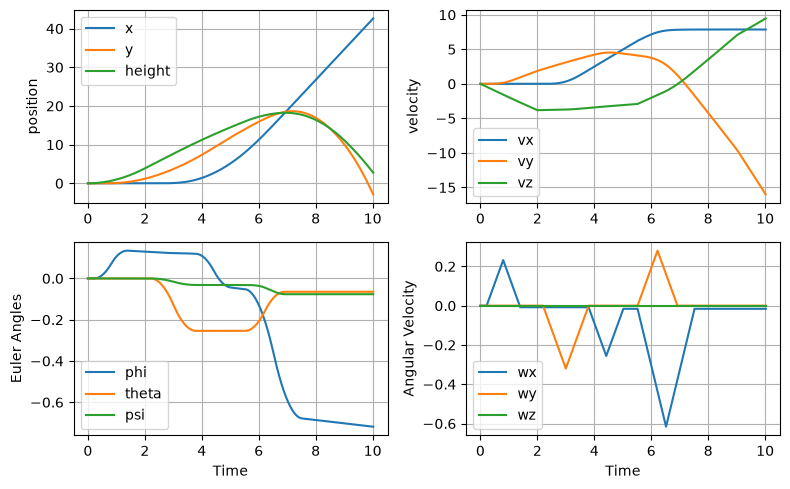

In [8]:
height = -df['z']
fig, axs = plt.subplots (2, 2, figsize = (8, 5))

axs[0, 0].plot (df['time'], df['x'], label = 'x')
axs[0, 0].plot (df['time'], df['y'], label = 'y')
axs[0, 0].plot (df['time'], height, label = 'height')
axs[0, 0].set_ylabel ('position') 
axs[0, 0].legend() 
axs[0, 0].grid (True)

axs[0, 1].plot (df['time'], df['vx'], label = 'vx')
axs[0, 1].plot (df['time'], df['vy'], label = 'vy')
axs[0, 1].plot (df['time'], df['vz'], label = 'vz')
axs[0, 1].set_ylabel ('velocity')
axs[0, 1].legend() 
axs[0, 1].grid(True)

axs[1, 0].plot (df['time'], (df['phi']), label = 'phi')
axs[1, 0].plot (df['time'], (df['theta']), label = 'theta')
axs[1, 0].plot (df['time'], (df['psi']), label = 'psi')
axs[1, 0].set_ylabel ('Euler Angles')
axs[1, 0].legend()
axs[1, 0].grid (True) 

axs[1, 1].plot (df['time'], df['wx'], label = 'wx')
axs[1, 1].plot (df['time'], df['wy'], label = 'wy')
axs[1, 1].plot (df['time'], df['wz'], label = 'wz')
axs[1, 1].set_ylabel ('Angular Velocity')
axs[1, 1].legend()
axs[1, 1].grid (True) 

axs[1, 0].set_xlabel('Time')
axs[1, 1].set_xlabel('Time')

plt.tight_layout()
plt.show() 

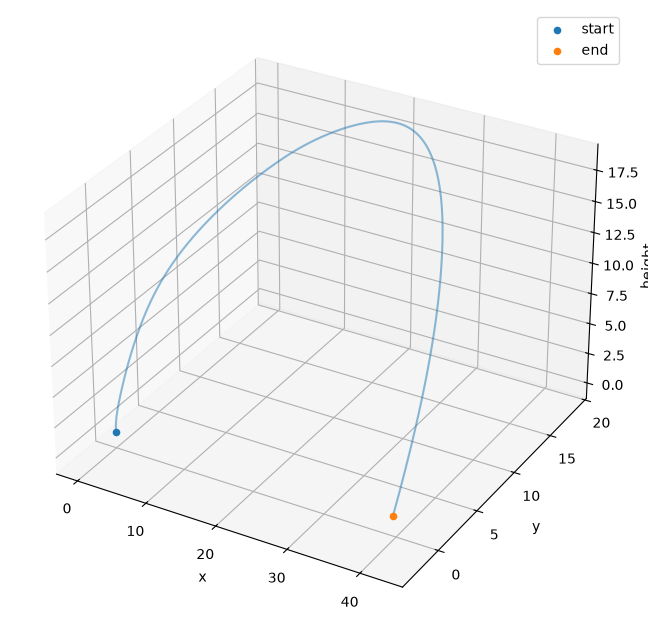

In [9]:
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot (projection = '3d')
ax.plot (df['x'], df['y'], height, alpha = 0.5)
ax.scatter (
    df['x'].iloc[0], 
    df['y'].iloc[0], 
    height.iloc[0],
    label = 'start', 
)
ax.scatter (
    df['x'].iloc[-1],
    df['y'].iloc[-1],
    height.iloc[-1],
    label = 'end'
)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('height')
ax.legend()

plt.show() 